Task1 - Data Loading & Exploration

In [28]:
import pandas as pd

In [29]:
#Load Dataset
df = pd.read_csv("Reviews.csv")

In [30]:
#Using only 5000 rows to keep it manageable
df = df.head(5000)

In [31]:
df.to_csv("Reviews_5000.csv", index=False)

In [32]:
# Displaying first 10 rows
df.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [33]:
# Shape of dataset
df.shape

(5000, 10)

In [34]:
# Column names
df.columns



#Column which contains review text = 'Text'
#Column which contains review score = 'Score'

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

Task2 — Data Cleaning

In [35]:
# Keeping only required columns text and score 
df = df[['Text', 'Score']]

In [36]:
# Remove null values
df = df.dropna()

In [37]:
# Remove duplicates
df = df.drop_duplicates()

In [38]:
df.shape

(4984, 2)

Task 3 — Sentiment Analysis

In [39]:
import sys
!{sys.executable} -m pip install --user textblob

In [40]:
from textblob import TextBlob

In [41]:
# Function to get sentiment
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

In [42]:
# Apply function
df['Polarity'] = df['Text'].apply(get_sentiment)

In [43]:
# Label sentiment
def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

In [44]:
df['Sentiment'] = df['Polarity'].apply(label_sentiment)

In [45]:
df.head()

,Text,Score,Polarity,Sentiment
0,I have bought several of the Vitality canned d...,5,0.450000,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333,Negative
2,This is a confection that has been around a fe...,4,0.133571,Positive
3,If you are looking for the secret ingredient i...,2,0.166667,Positive
4,Great taffy at a great price. There was a wid...,5,0.483333,Positive


Task 4 — Visualization

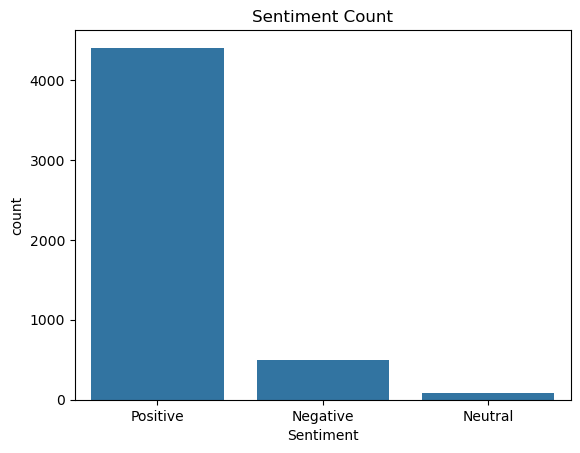

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Count")
plt.savefig("charts/bar_chart.png")
plt.show()

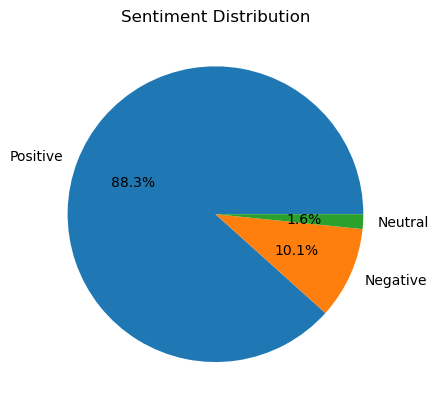

In [47]:
df['Sentiment'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.ylabel('')
plt.savefig("charts/pie_chart.png")
plt.show()

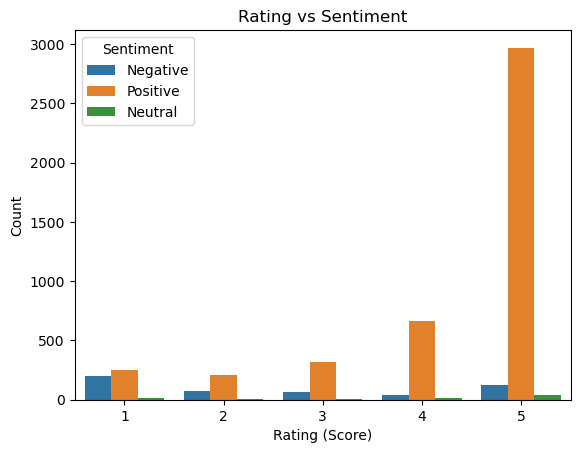

In [48]:
# Count plot with hue
sns.countplot(x='Score', hue='Sentiment', data=df)

plt.title("Rating vs Sentiment")
plt.xlabel("Rating (Score)")
plt.ylabel("Count")

plt.savefig("charts/rating_vs_sentiment.png")
plt.show()

Task 5 — Insights & Summary 

I observed that around 88% of the reviews are positive, which shows that most customers are highly satisfied with the products.
From the negative reviews, I noticed that customers mainly complain about bad taste, packaging issues, and inconsistent product quality.
One surprising observation was that even products with a 5-star rating still had some negative reviews, showing mixed customer experiences.
I also observed that neutral reviews are very few (around 1–2%) and most of them are short with less detailed feedback.
The rating vs sentiment chart clearly shows that higher ratings (4–5) have mostly positive sentiment, while lower ratings have more negative sentiment.
Based on my analysis, I would recommend that the business should focus on improving product consistency and packaging quality to reduce negative reviews.